In [1]:
# Setup
!pip install pandas numpy seaborn matplotlib scikit-learn tensorflow joblib

In [2]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import joblib

In [3]:
# Load Data
from google.colab import files
uploaded = files.upload()
cols = ['pace','shooting','passing','dribbling','defending','physic','overall','club_name']
df_male = pd.read_csv('Male Players.csv', usecols=cols, low_memory=False)
df_female = pd.read_csv('Female Players.csv', usecols=cols, low_memory=False)

Saving Female Players.csv to Female Players.csv
Saving Male Players.csv to Male Players.csv


In [4]:
# Add Gender & Merge
df_male['gender'] = 0
df_female['gender'] = 1
df = pd.concat([df_male, df_female], ignore_index=True)

In [5]:
# Cleaning
df.rename(columns={'physic': 'physical'}, inplace=True)
df = df.dropna()
df.reset_index(drop=True, inplace=True)
print(df.shape)

(160404, 9)


In [6]:
# EDA
# Numeric
numeric_df = df.select_dtypes(include=['number'])

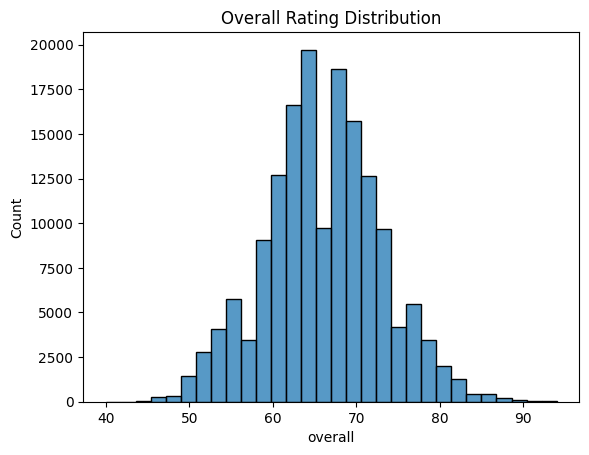

In [7]:
# Distribution
plt.figure()
sns.histplot(df['overall'], bins=30)
plt.title("Overall Rating Distribution")
plt.show()

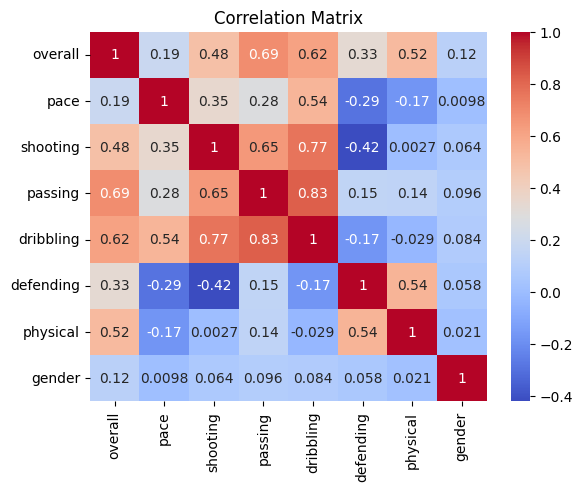

In [8]:
# Correlation
plt.figure()
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

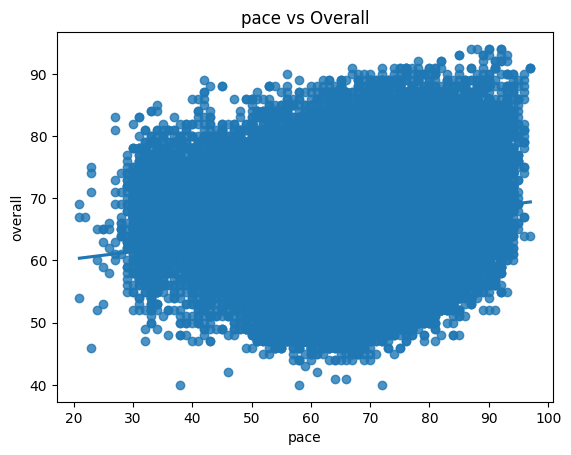

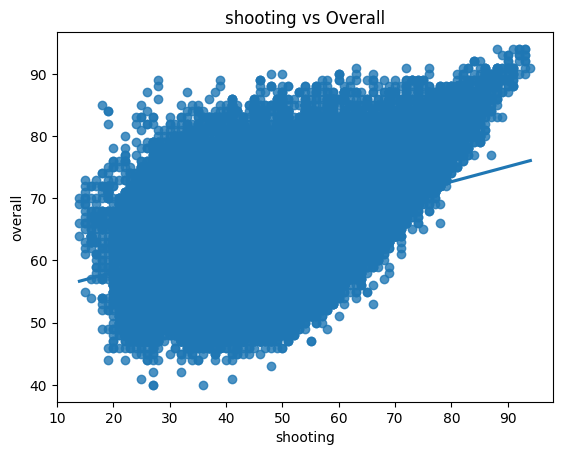

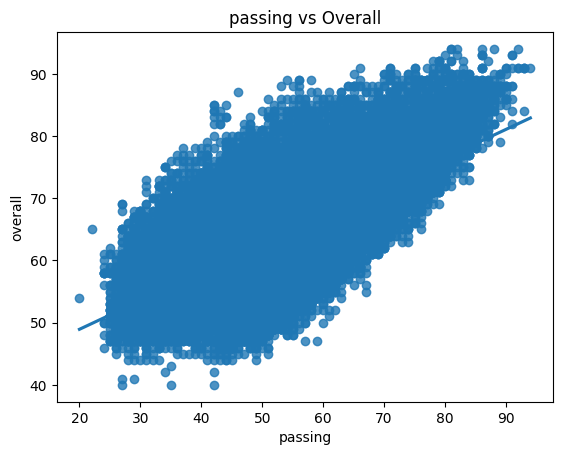

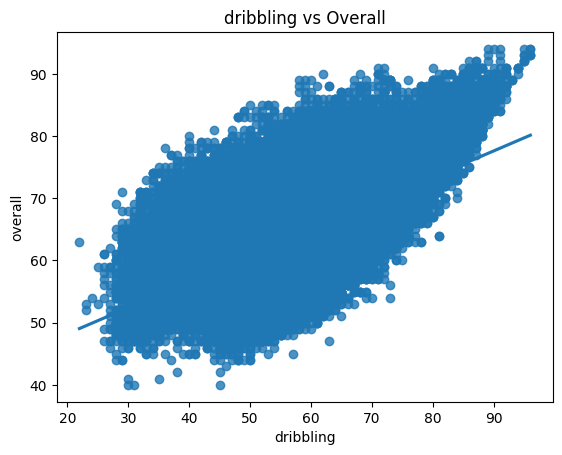

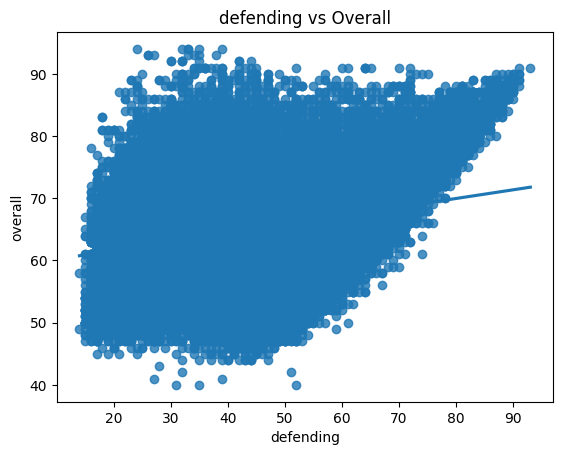

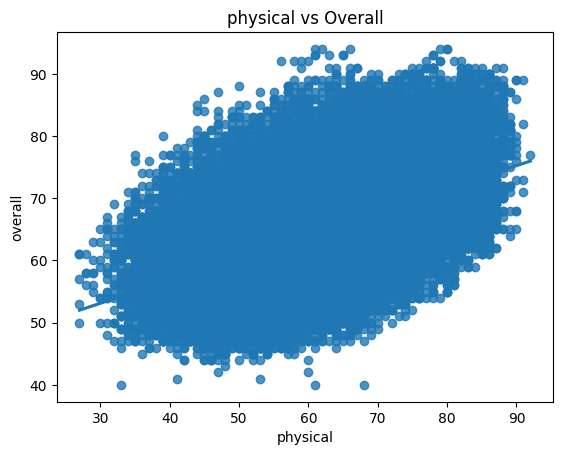

In [9]:
# Feature vs Target
features = ['pace','shooting','passing','dribbling','defending','physical']
for col in features:
    plt.figure()
    sns.regplot(x=df[col], y=df['overall'])
    plt.title(f"{col} vs Overall")
    plt.show()

In [10]:
# Train-Test Split
X = df[['pace','shooting','passing','dribbling','defending','physical','gender']]
y = df['overall']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Model
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
model = Sequential([
    Input(shape=(7,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

In [14]:
# Training
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
3209/3209 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 139.5201 - val_loss: 3.1458
Epoch 2/30
3209/3209 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 27.9078 - val_loss: 2.8751
Epoch 3/30
3209/3209 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 17.9384 - val_loss: 2.5462
Epoch 4/30
3209/3209 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 11.7680 - val_loss: 2.4646
Epoch 5/30
3209/3209 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 6.2709 - val_loss: 2.2055
Epoch 6/30
3209/3209 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 3.9040 - val_loss: 2.3263
Epoch 7/30
3209/3209 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 3.3838 - val_loss: 2.1062
Epoch 8/30
3209/3209 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 3.0474 - val_loss: 2.1662
Epoch 9/30
3209/3209 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 2.8636 - val_loss: 2.1315
Epoch 10/30
3209/3209 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 2.7430 - val_loss: 2.1766
Epoch 11/30
3209/3209 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 2.6945 - val_loss: 2.5596
Epoch 12/30
3209

In [15]:
# Evaluation
pred = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)
print("RMSE:", rmse)
print("R2:", r2)

1003/1003 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
RMSE: 1.6616386706341504
R2: 0.9434846639633179


In [16]:
# Save Models
model.save("player_model.keras")
joblib.dump(scaler, "scaler.pkl")
df.to_csv("clean_players.csv", index=False)